# 10주차_머신러닝 분석 방법론 Ⅰ

- 의사결정나무와 랜덤 포레스트(예측/분류 모델)

---

In [ ]:
# 필요한 패키지 설치
from sklearn.preprocessing import MinMaxScaler
# MinMaxScaler 클래스를 불러옴 → 모든 수치형 데이터를 0~1 범위로 정규화함
# 각 변수의 최소값은 0, 최대값은 1이 되도록 선형 변환하여 서로 다른 단위를 동일한 스케일로 맞추는 데 사용됨

from sklearn.model_selection import train_test_split
# 데이터를 학습용과 테스트용으로 무작위 분할하는 함수 train_test_split을 불러옴
# 모델 평가의 신뢰성을 확보하기 위해 훈련 데이터와 평가 데이터를 분리하는 데 사용됨

from sklearn.tree import DecisionTreeClassifier
# 의사결정나무(Decision Tree) 분류 모델 클래스 불러옴
# 데이터의 조건 분기를 따라가며 예측하는 트리 기반 모델이며, 직관적 해석과 시각화가 용이함

import pydotplus
# 트리 모델을 시각화 가능한 그래픽 구조로 변환하기 위해 사용하는 외부 시각화 도구 패키지임
# Graphviz 언어로 만들어진 구조를 이미지로 변환할 수 있는 기능 제공함

from sklearn.tree import export_graphviz
# 의사결정나무 모델을 .dot 포맷(그래프 언어)으로 출력할 수 있는 함수 불러옴
# 시각화 도구(pydotplus 등)와 결합하여 트리 구조를 이미지로 표현할 수 있게 함

from IPython.core.display import Image
# 주피터 노트북 환경에서 생성된 이미지(png 등)를 화면에 출력하기 위한 클래스 불러옴
# export_graphviz → pydotplus → Image의 순서로 시각화 흐름이 구성됨

from sklearn.metrics import accuracy_score
# 예측 결과와 실제 정답을 비교하여 분류 모델의 정확도(Accuracy)를 계산하는 함수 불러옴
# 전체 예측 중 맞춘 비율을 정량적으로 평가하는 가장 기본적인 성능 지표임

from sklearn.ensemble import RandomForestClassifier
# 랜덤포레스트 분류기(Random Forest Classifier)를 불러옴
# 여러 개의 의사결정나무를 결합하여 더 높은 정확도와 일반화 성능을 가지는 앙상블 모델을 구현함
# 과적합을 줄이고 예측 안정성을 높이기 위한 대표적인 앙상블 기법임

from sklearn.metrics import classification_report
# 정밀도(precision), 재현율(recall), F1-score 등의 주요 분류 성능 지표를 포괄적으로 출력하는 함수 불러옴
# 이진 또는 다중 클래스 분류 결과에 대해 더 정밀한 성능 해석을 가능하게 함

import pandas as pd
# pandas 데이터프레임 라이브러리를 불러옴 → 표 형태의 데이터 처리, 분석, 정리 작업에 필수적인 도구로 사용됨

import numpy as np
# numpy 수치 연산 라이브러리를 불러옴 → 다차원 배열 연산, 벡터/행렬 처리, 통계 분석의 기반이 되는 수치 계산 도구임

import seaborn as sns
# seaborn 시각화 라이브러리를 불러옴 → 통계적 시각화에 특화된 고수준 그래프 도구 제공
# 변수 간 상관관계, 분포, 카운트 등 데이터의 구조를 직관적으로 표현할 수 있음

import matplotlib.pyplot as plt
# matplotlib의 기본 시각화 도구인 pyplot을 불러옴 → 선형 그래프, 막대그래프, 산점도 등 일반적인 그래프를 생성함
# seaborn과 함께 사용되어 그래프 출력을 담당함


In [26]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/uciml/glass
df = pd.read_csv("../../../main/datasets/glass.csv")

# 데이터 샘플 확인
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [27]:
# 컬럼 정보 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [29]:
# 종속변수 문자형 변환

df["Type_str"] = df["Type"].apply(str)
# 'Type' 열의 값을 정수형에서 문자열(str) 형태로 변환하여 'Type_str'이라는 새 열에 저장함
# 다중 클래스 분류를 위한 시각화(예: seaborn의 hue 옵션 사용 시)나 범주형 인식이 필요한 알고리즘에서 활용 가능함
# 숫자로 구성된 클래스가 의미상 범주형(예: 1, 2, 3 → 유리 종류)이므로 명확하게 범주형으로 표현하려는 목적 수행
# 이후 시각화나 라벨 인코딩 등 과정에서 문자열 형식의 클래스가 더 직관적이고 유용할 수 있음

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type,Type_str
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1,1


In [ ]:
df['Type_str'].unique()

array(['1', '2', '3', '5', '6', '7'], dtype=object)

In [41]:
df['Type_str'].value_counts().sort_index()

1    70
2    76
3    17
5    13
6     9
7    29
Name: Type_str, dtype: int64

In [30]:
# 의사결정나무 모델 용 데이터셋 가공

# 독립변수, 종속변수 분리
df_x = df[['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']]
# 입력 피처(독립변수)로 사용할 9개의 연속형 특성만 추출하여 df_x로 저장함
# 이들은 유리의 물리·화학적 성분을 나타내며, 각각의 조합이 유리 종류를 구분하는 데 사용됨

df_y = df[['Type_str']]
# 문자열로 변환된 유리 종류를 종속변수로 지정함
# 다중 클래스 분류를 위한 타겟 데이터이며, 학습 대상인 클래스 레이블로 활용됨

# 학습셋과 테스트셋 분리하여 생성(6:4)
x_train, x_test, y_train, y_test = train_test_split(
    df_x, df_y, test_size=0.4, random_state=10)
# 전체 데이터셋을 학습용(60%)과 테스트용(40%)으로 무작위 분할함
# test_size=0.4는 전체의 40%를 평가용 테스트셋으로 사용하겠다는 의미임
# random_state=10은 실행할 때마다 같은 분할 결과를 재현하기 위한 시드 고정 역할을 수행함

# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(x_train))
# 학습용 데이터 샘플 수를 출력함 → 의도한 분할 비율대로 분할되었는지 확인하는 검증 단계임

print('test data 개수: ', len(x_test))
# 테스트용 데이터 샘플 수를 출력함 → 학습/평가용 데이터가 균형 있게 나뉘었는지 검토하는 확인 절차임


train data 개수:  128
test data 개수:  86


In [31]:
# 의사결정나무 모델 적용

# 모델 생성 및 학습
dt_model = DecisionTreeClassifier(criterion = "entropy", max_depth=5)
# 의사결정나무 분류 모델 객체를 생성함
# criterion="entropy"는 정보이득(Information Gain)을 기준으로 노드를 분할하도록 설정함
# max_depth=5는 트리의 최대 깊이를 5로 제한함 → 과적합 방지를 위한 규제 역할을 수행함

dt_model.fit(x_train, y_train)
# 학습용 입력 데이터(x_train)와 타겟(y_train)을 사용하여 의사결정나무 모델을 훈련시킴
# 트리 구조 내부에서 각 변수의 조건에 따라 데이터를 분기하여 유리 종류를 분류할 수 있는 규칙을 학습함

# 테스트셋 예측
y_pred = dt_model.predict(x_test)
# 학습된 의사결정나무 모델을 테스트셋에 적용하여 유리 종류를 예측함
# 예측 결과는 테스트셋의 각 샘플에 대해 예측된 클래스 레이블을 담은 배열 형태로 반환됨

# 정확도 계산
accuracy_score(y_test, y_pred)
# 테스트셋에서 실제 정답(y_test)과 모델 예측값(y_pred)을 비교하여 정확도(Accuracy)를 계산함
# 정확도는 전체 샘플 중에서 정답을 맞힌 비율로, 모델의 분류 성능을 평가하는 가장 기본적인 지표임


0.627906976744186

In [33]:
# 독립변수 중요도 확인

dt_model.feature_importances_
# 학습된 의사결정나무 모델에서 각 독립변수가 얼마나 중요한지를 수치로 출력함
# 중요도는 각 피처가 트리에서 분기를 만드는 데 얼마나 기여했는지를 기준으로 계산됨
# 분할 시 정보이득(entropy 감소량)이 큰 변수일수록 높은 중요도를 가짐
# 출력값은 모든 변수 중요도의 합이 1이 되도록 정규화된 형태로 반환됨




array([0.04569901, 0.10029594, 0.32014161, 0.2203041 , 0.1368652 ,
       0.01702037, 0.15967378, 0.        , 0.        ])

In [34]:
pd.DataFrame({
    'feature' : x_train.columns,
    'importance' : dt_model.feature_importances_
})
# 독립변수의 이름과 해당 변수의 중요도를 하나의 데이터프레임으로 정리함
# 각 변수명이 어떤 특성(RI, Na, Mg 등)에 해당하며, 그 특성이 예측에 얼마나 영향을 주었는지를 쉽게 해석할 수 있도록 구성함
# 결과를 보면, 값이 클수록 모델 예측에서 해당 변수가 더 자주 사용되었고 더 큰 영향을 미쳤음을 의미함
# 변수 선택(feature selection) 또는 도메인 해석 시 유용한 인사이트를 제공함

,feature,importance
0,RI,0.045699
1,Na,0.100296
2,Mg,0.320142
3,Al,0.220304
4,Si,0.136865
5,K,0.017020
6,Ca,0.159674
7,Ba,0.000000
8,Fe,0.000000


In [42]:
# 의사결정나무 시각화

# out_file=None : 결과를 파일로 저장하지 않겠다.
# filled=True : 상자 채우기
# rounded=True : 상자모서리 둥그렇게 만들기
# special_characters=True : 상자안에 내용 넣기

# 시각화 세부 옵션 설정
dot_data = export_graphviz(
    dt_model,                        # 학습된 의사결정나무 모델 객체
    out_file=None,                   # .dot 파일로 저장하지 않고, 문자열 형태로 반환함
    feature_names=x_train.columns,   # 각 노드에서 표시할 독립변수 이름 설정
    class_names=dt_model.classes_,   # 클래스 이름 설정 → 타겟 레이블에 해당하는 문자열들 표시
    filled=True,                     # 노드 상자를 색상으로 채워서 클래스별로 시각적으로 구분 가능하게 설정함
    rounded=True,                    # 노드 상자의 모서리를 둥글게 만들어 가독성을 높임
    special_characters=True          # 텍스트 안에 특수문자 허용 설정 (예: ≤ 등)
)
# 이 함수는 Graphviz의 .dot 형식 문자열을 생성하여, 이후 pydotplus 등 시각화 라이브러리로 이미지 변환이 가능하게 함

# 시각화
dot_data
# .dot 형식의 트리 구조 문자열을 출력함 (선택 사항)

'digraph Tree {\nnode [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label=<Mg &le; 2.7<br/>entropy = 2.105<br/>samples = 128<br/>value = [40, 50, 10, 5, 5, 18]<br/>class = 2>, fillcolor="#f4fce8"] ;\n1 [label=<Ca &le; 10.02<br/>entropy = 1.765<br/>samples = 33<br/>value = [0, 6, 0, 5, 5, 17]<br/>class = 7>, fillcolor="#f4aed7"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label=<Si &le; 72.805<br/>entropy = 1.123<br/>samples = 24<br/>value = [0, 0, 0, 2, 5, 17]<br/>class = 7>, fillcolor="#ef82c1"] ;\n1 -> 2 ;\n3 [label=<Al &le; 1.9<br/>entropy = 1.436<br/>samples = 9<br/>value = [0, 0, 0, 2, 5, 2]<br/>class = 6>, fillcolor="#c9aaf4"] ;\n2 -> 3 ;\n4 [label=<entropy = 0.0<br/>samples = 5<br/>value = [0, 0, 0, 0, 5, 0]<br/>class = 6>, fillcolor="#8139e5"] ;\n3 -> 4 ;\n5 [label=<Na &le; 14.075<br/>entropy = 1.0<br/>samples = 4<br/>value = [0, 0, 0, 2, 0, 2]<br/>class = 5>, fillcolor="#ffffff"] ;\n3 -> 

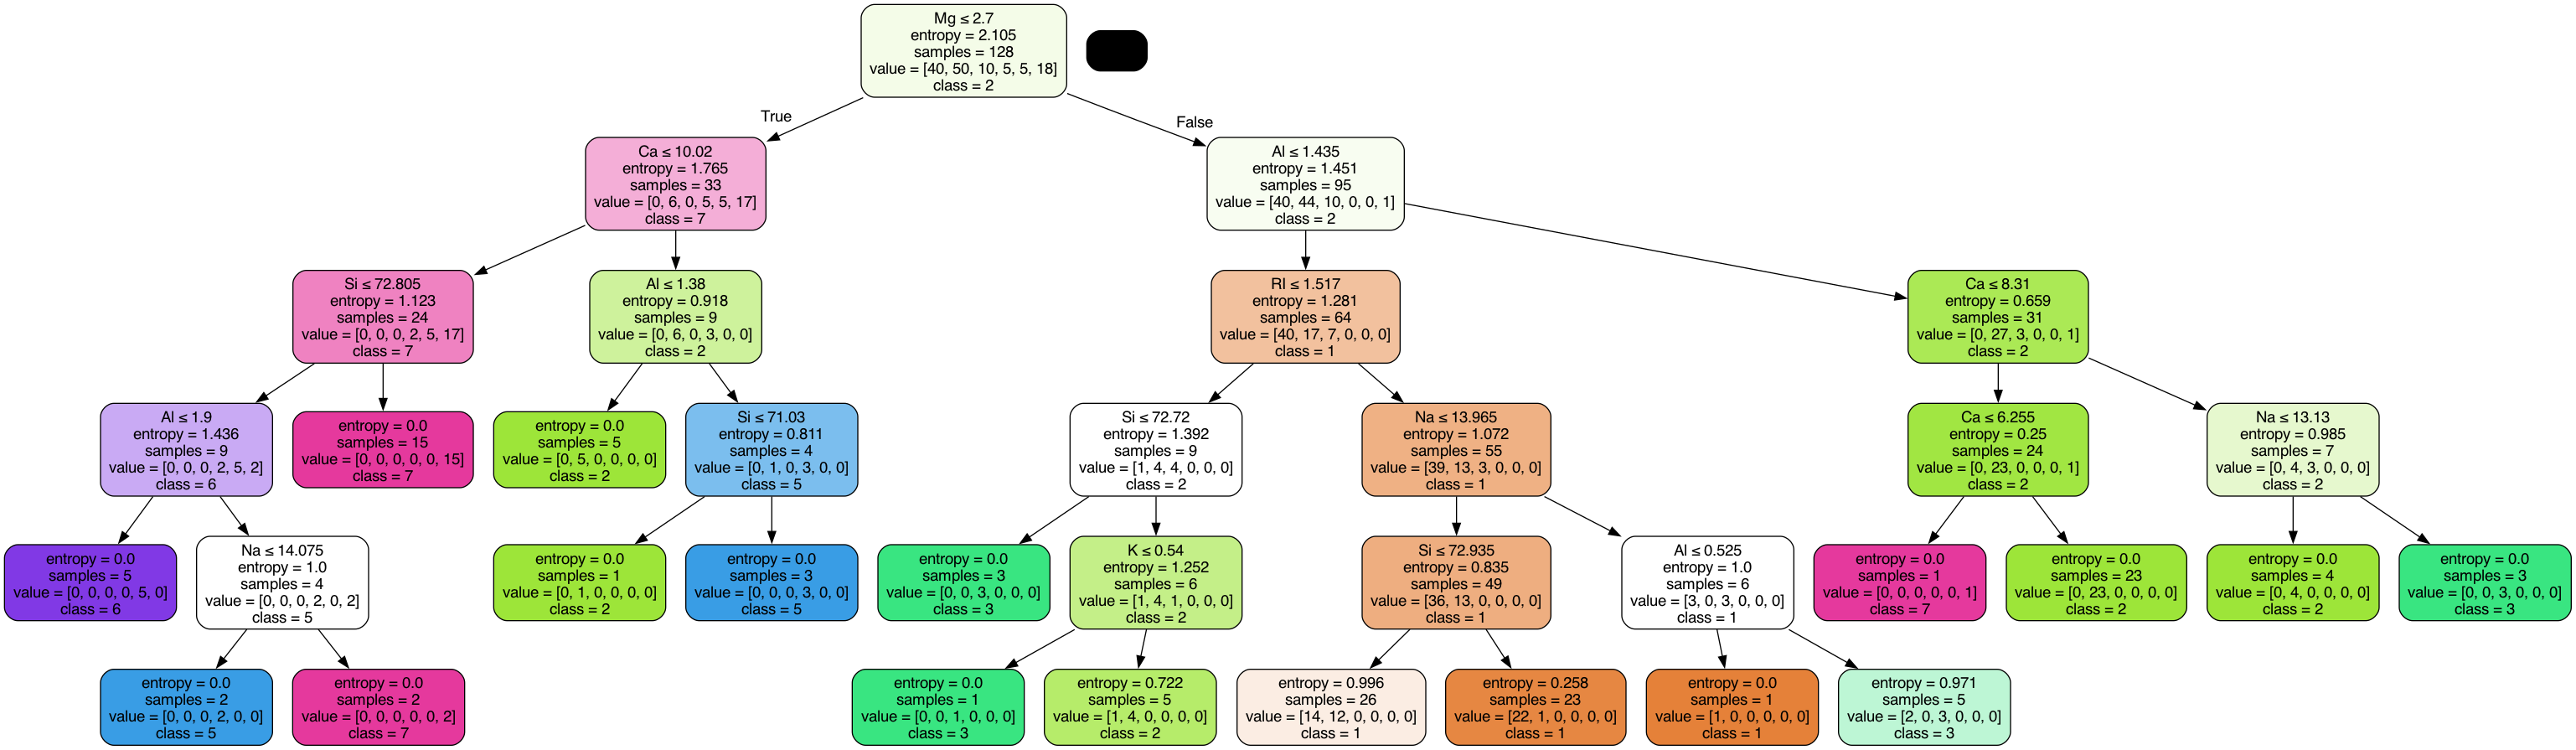

In [44]:
graph = pydotplus.graph_from_dot_data(dot_data)
# dot_data를 바탕으로 pydotplus 라이브러리를 사용해 트리 그래프 객체를 생성함
# 이 객체는 이미지(png, pdf 등)로 저장하거나 화면에 표시할 수 있음

Image(graph.create_png())
# 생성된 그래프 객체를 .png 이미지로 변환하여 IPython 환경(예: Jupyter Notebook)에서 시각적으로 출력함
# 결과적으로 트리 구조의 분기 조건, 예측 클래스, 샘플 수, 클래스별 비율 등을 시각적으로 확인할 수 있음


In [45]:
# 랜덤포레스트 모델 생성

# 기본 모델
# rnf_model = RandomForestClassifier(n_estimators=100, max_depth=5,random_state=0)
# 위는 간단한 기본 설정으로 생성한 랜덤포레스트 분류기이며, 아래는 모든 주요 하이퍼파라미터를 명시한 확장 버전임

rnf_model = RandomForestClassifier(
    n_estimators=100,               # 생성할 트리(결정나무)의 개수를 100개로 설정함 → 앙상블의 크기를 의미함
    max_depth=5,                    # 각 결정나무의 최대 깊이를 5로 제한하여 과적합을 방지함
    random_state=0,                 # 결과 재현성을 위한 난수 시드 고정

    bootstrap=True,                 # 부트스트래핑 사용 여부 → 학습 샘플을 중복 추출하여 각 트리를 학습시킴
    class_weight=None,              # 클래스별 가중치 → None이면 모든 클래스에 동일 가중치 적용
    criterion='gini',               # 분할 기준으로 지니 불순도(Gini impurity)를 사용함
    max_features='sqrt',            # 각 노드에서 분할에 사용할 피처 수를 전체의 제곱근으로 제한함 → 무작위성 증가, 과적합 방지 효과

    max_leaf_nodes=None,            # 말단 노드 최대 개수 제한 없음
    min_impurity_decrease=0.0,      # 노드를 분할하기 위한 최소 불순도 감소 조건 설정
    min_samples_leaf=1,             # 말단 노드가 되기 위한 최소 샘플 수
    min_samples_split=2,            # 노드를 분할하기 위한 최소 샘플 수
    min_weight_fraction_leaf=0.0,   # 샘플 가중치 기반 말단 노드 최소 조건 비율 (기본 비활성화)

    n_jobs=None,                    # 병렬 처리 시 사용할 CPU 코어 수 (None이면 1개)
    oob_score=False,                # Out-of-Bag 샘플로 일반화 성능을 평가할지 여부 (여기선 비활성화)
    verbose=0,                      # 학습 중 출력 메시지 수준 설정 (0은 비표시)
    warm_start=False                # 이전 결과를 유지하고 추가 트리를 학습할지 여부 (False는 항상 새로 학습)
)

rnf_model.fit(x_train, y_train)
# 훈련용 데이터(x_train, y_train)를 이용해 랜덤포레스트 모델을 학습함
# 각 결정트리가 일부 데이터 및 일부 피처를 랜덤하게 사용해 학습되며, 앙상블 효과로 일반화 성능을 향상시킴

y_pred = rnf_model.predict(x_test)
# 학습된 랜덤포레스트 모델을 테스트셋에 적용하여 유리 종류를 예측함
# 각 트리의 예측 결과를 다수결 방식으로 종합하여 최종 예측을 수행함

print(accuracy_score(y_test, y_pred))
# 예측값(y_pred)과 실제값(y_test)을 비교하여 정확도(Accuracy)를 계산하고 출력함
# 정확도는 전체 샘플 중 정답을 맞힌 비율이며, 분류 모델의 성능을 대표하는 기본적인 평가 지표임


0.7093023255813954


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [46]:
# 랜덤포레스트 모델 성능 리포트 출력

print(classification_report(y_test, y_pred))
# 테스트셋의 실제 정답(y_test)과 모델 예측값(y_pred)을 비교하여 분류 성능 리포트를 출력함
# 출력 항목은 다음과 같음:

# 1. precision (정밀도)
#  → 해당 클래스로 예측된 것들 중 실제로 맞춘 비율
#  → False Positive(거짓 양성)를 얼마나 줄였는지 평가함

# 2. recall (재현율)
#  → 실제 해당 클래스인 것들 중 맞춘 비율
#  → False Negative(거짓 음성)를 얼마나 줄였는지 평가함

# 3. f1-score
#  → 정밀도와 재현율의 조화 평균 (두 지표가 균형을 이룰 때 높게 나옴)
#  → 불균형 데이터셋에서 특히 유용한 평가 지표임

# 4. support
#  → 각 클래스의 실제 데이터 개수 (샘플 수)

# 이 리포트를 통해 다중 클래스 분류 문제에서 어떤 클래스가 잘 예측되고, 어떤 클래스가 성능이 낮은지를 직관적으로 확인할 수 있음
# 전체 평균 성능도 함께 출력되어 모델 전반의 균형성과 신뢰성을 평가하는 데 도움을 줌


              precision    recall  f1-score   support

           1       0.69      0.73      0.71        30
           2       0.62      0.77      0.69        26
           3       0.67      0.29      0.40         7
           5       1.00      0.75      0.86         8
           6       0.50      0.25      0.33         4
           7       0.91      0.91      0.91        11

    accuracy                           0.71        86
   macro avg       0.73      0.62      0.65        86
weighted avg       0.72      0.71      0.70        86



In [47]:
# 랜덤포레스트 변수 중요도 출력

feature_imp = pd.Series(
    rnf_model.feature_importances_, 
    index=x_train.columns
).sort_values(ascending=False)
# 랜덤포레스트 모델(rnf_model)로부터 각 독립변수의 중요도를 추출함
# feature_importances_는 각 피처가 전체 트리의 분기에서 얼마나 많이 사용되었는지를 비율로 나타낸 수치임
# 이 값은 0~1 사이의 값이며, 모든 변수 중요도의 합은 1이 되도록 정규화되어 있음
# pd.Series로 변수명(index)과 중요도(value)를 매칭하여 시리즈 객체로 구성하고, 중요도 기준으로 내림차순 정렬함
# 가장 영향을 많이 준 변수부터 위에 오도록 정렬하여 해석과 시각화를 용이하게 함

feature_imp[:20]
# 중요도가 높은 상위 20개 변수만 출력함
# 다만 현재 유리 데이터셋은 특성 변수가 9개뿐이므로 실제로는 상위 9개만 표시될 수 있음
# 이 결과를 통해 어떤 화학 성분(RI, Mg 등)이 유리의 종류 분류에 더 큰 기여를 하는지를 직관적으로 파악할 수 있음


Al    0.159236
Ca    0.153955
Mg    0.148816
RI    0.140340
Na    0.107429
Ba    0.090783
K     0.079957
Si    0.072767
Fe    0.046717
dtype: float64

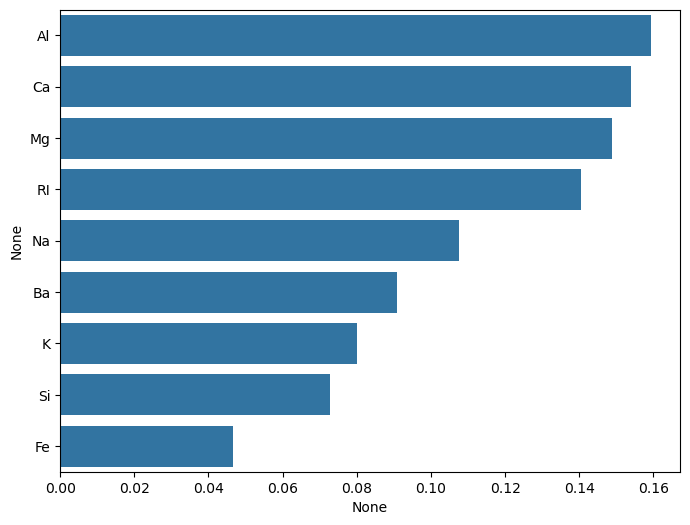

In [ ]:
# 랜덤포레스트 변수 중요도 시각화

plt.figure(figsize=(8, 6))
# 시각화 그래프의 전체 크기를 너비 8, 높이 6인치로 설정함
# 그래프가 너무 작거나 글자가 겹치는 것을 방지하기 위한 시각화 설정 단계임

sns.barplot(x=feature_imp, y=feature_imp.index)
# seaborn의 barplot 함수를 사용하여 변수 중요도 시각화를 수행함
# x축은 변수 중요도 값, y축은 해당 변수의 이름으로 설정함
# index 순서가 이미 중요도 기준으로 정렬되어 있기 때문에 가장 중요한 변수가 위쪽에 배치됨
# 막대 그래프의 길이가 길수록 해당 변수가 분류 문제에서 중요한 역할을 했다는 의미임

plt.show()
# 설정한 그래프를 화면에 출력함
# 시각적으로 어떤 변수가 예측에 가장 큰 영향을 주었는지를 직관적으로 파악할 수 있음
